# **Assignment 1**

##### Author: Simen Roko Krogstie

#### Accounts


- My GitHub repo can be found [here](https://github.com/SimenKrogstie/D2D_SRK)
- My Streamlit app can be found [here](https://d2dsrk.streamlit.app/)

#### Imports

In [1]:
# Importing necessary libraries
from pathlib import Path
import pandas as pd 
import matplotlib.pyplot as plt 

DATA_PATH = Path.cwd().parent / "data" / "reservoirs.csv"

#### Read data

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["dato_Id"])

#### Rename columns to english and understandable terms

In [5]:
# Plotting the column names
df.columns

Index(['dato_Id', 'omrType', 'omrnr', 'iso_aar', 'iso_uke', 'fyllingsgrad',
       'kapasitet_TWh', 'fylling_TWh', 'neste_Publiseringsdato',
       'fyllingsgrad_forrige_uke', 'endring_fyllingsgrad'],
      dtype='str')

In [6]:
# Renaming columns to more understandeble terms, and translating to english
df = df.rename(columns={
    "dato_Id"                   : "date",                    
    "omrType"                   : "area_type",                   
    "omrnr"                     : "area_number",             
    "iso_aar"                   : "iso_year",                  
    "iso_uke"                   : "iso_week",                    
    "fyllingsgrad"              : "fill_degree",                 
    "kapasitet_TWh"             : "capacity_TWh",                
    "fylling_TWh"               : "filling_TWh",                  
    "neste_Publiseringsdato"    : "next_publish_date",            
    "fyllingsgrad_forrige_uke"  : "fill_degree_prev_week",        
    "endring_fyllingsgrad"      : "change_in_fill_degree"            
})

#### Print contents of DataFrame in a meaningful way

In [7]:
# Print head of dataframe
df.head()

,date,area_type,area_number,iso_year,iso_week,fill_degree,capacity_TWh,filling_TWh,next_publish_date,fill_degree_prev_week,change_in_fill_degree
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [8]:
# Basic statistical distributions
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,14877,2010-11-07 00:00:00,1995-01-08 00:00:00,2002-12-08 00:00:00,2010-11-07 00:00:00,2018-10-07 00:00:00,2026-09-06 00:00:00,NaN
area_number,14877.0,2.333333,0.0,1.0,2.0,3.0,5.0,1.490762
iso_year,14877.0,2010.346038,1995.0,2002.0,2010.0,2018.0,2026.0,9.146696
iso_week,14877.0,26.405929,1.0,13.0,26.0,39.0,53.0,15.01791
fill_degree,14877.0,0.618852,0.05516,0.456234,0.648049,0.802135,1.020072,0.21485
capacity_TWh,14877.0,29.14586,6.003264,17.390587,23.237715,34.04359,87.43758,22.73907
filling_TWh,14877.0,18.139713,0.331142,7.321973,14.501389,22.20353,84.54482,15.966211
fill_degree_prev_week,14877.0,0.61889,0.05516,0.456356,0.648114,0.802133,1.020037,0.214843
change_in_fill_degree,14877.0,-0.000038,-0.242484,-0.022395,-0.007072,0.016277,0.336623,0.031385


In [9]:
# Print how many unique values there are per column
df.nunique()

date                      1653
area_type                    3
area_number                  6
iso_year                    32
iso_week                    53
fill_degree              14868
capacity_TWh                 9
filling_TWh              14871
next_publish_date          396
fill_degree_prev_week    14868
change_in_fill_degree    14828
dtype: int64

#### Plot each column separately

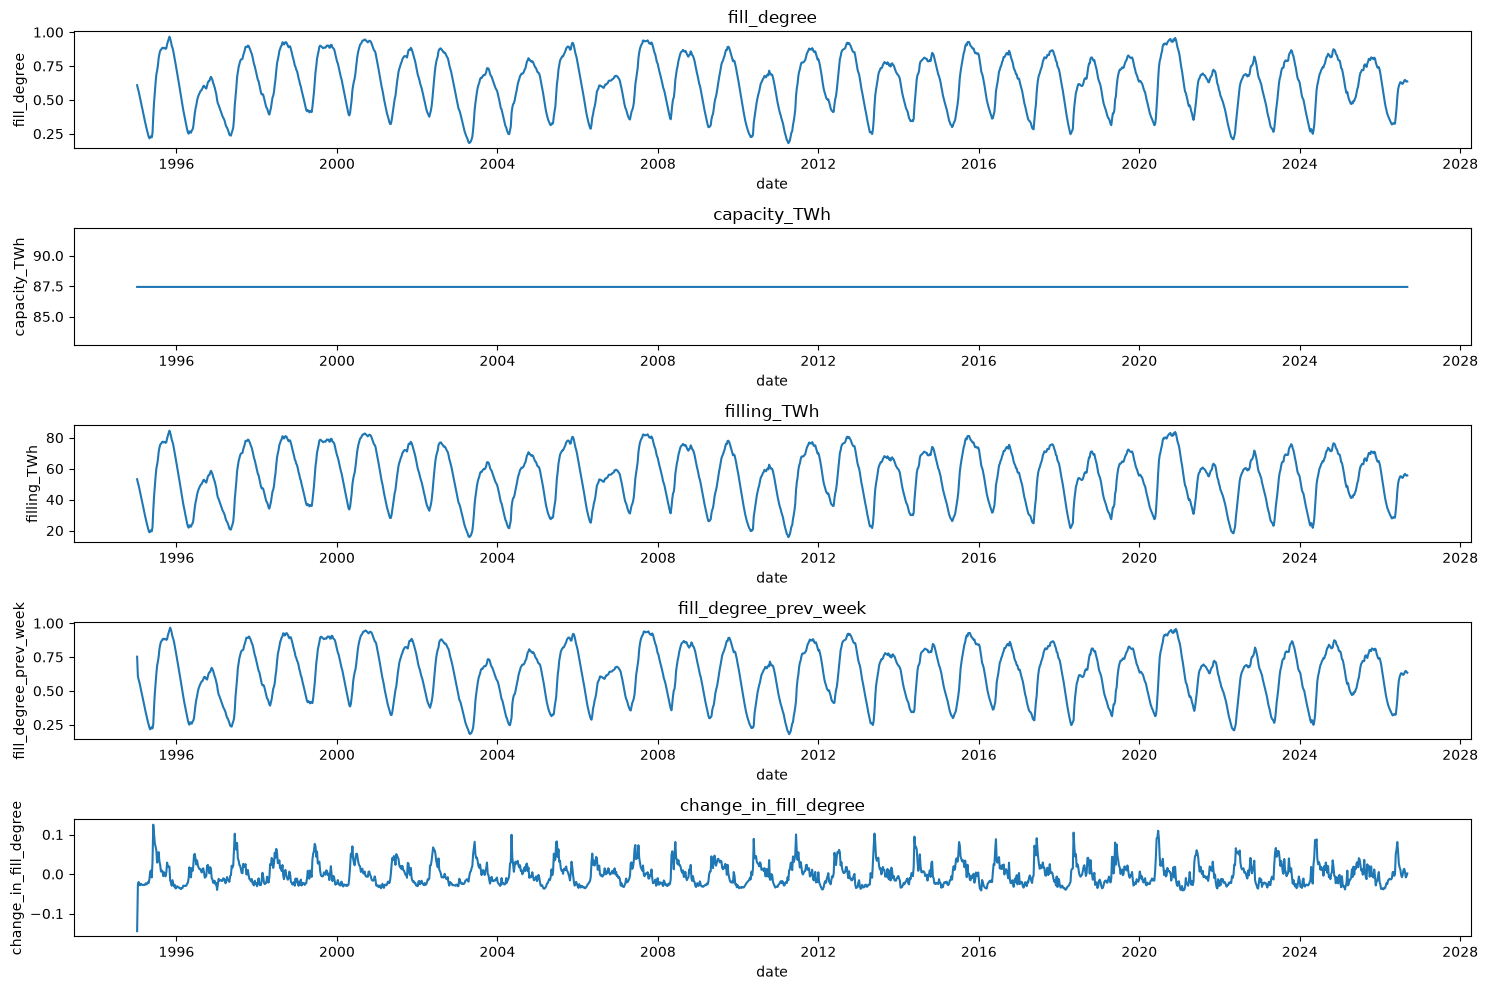

In [10]:
# Select numneric columns that isnt an identifier
numeric_cols = ["fill_degree", "capacity_TWh", "filling_TWh",
                "fill_degree_prev_week", "change_in_fill_degree"]

df_no = (
    df.loc[df["area_type"] == "NO", ["date"] + numeric_cols]
    .set_index("date")
    .sort_index()
)

# Initialize a figure for plotting each column
fig, axes = plt.subplots(len(numeric_cols), figsize=(15, 10))

# Plotting each column in the figure
for col, ax in zip(df_no.columns, axes.ravel()):
    ax.plot(df_no.index, df_no[col])
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.set_xlabel("date")

plt.tight_layout()
plt.show()

### Comment

#### Plot all columns together

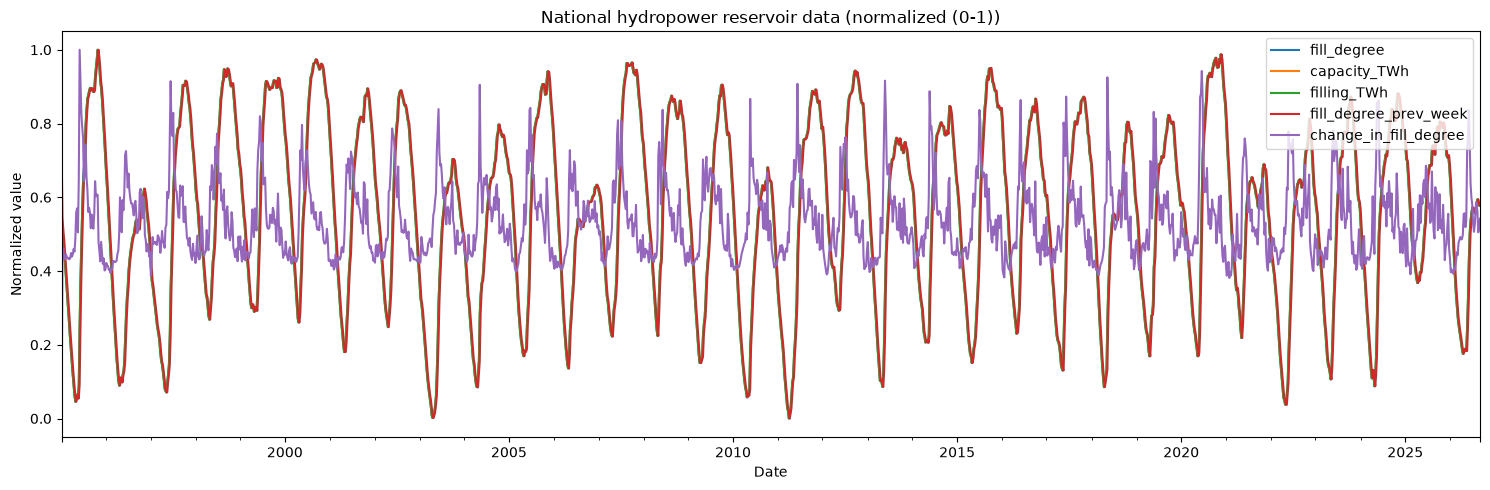

In [11]:
# Normalizing the columns in df_no such that they are comparable
df_norm = (df_no - df_no.min()) / (df_no.max() - df_no.min())

# Plotting the columns in one plot
df_norm.plot(figsize=(15, 5))
plt.title("National hydropower reservoir data (normalized (0-1))")
plt.xlabel("Date")
plt.ylabel("Normalized value")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Comment

## Streamlit app

### Log and AI usage


### Page 2 - Table

In [ ]:
!cat ../pages/2_table.py